# Counterfactual Generation for Spiral Dataset

## 1 – Setup and Imports

In [2]:
import numpy as np
import torch
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt

from preimage_sampling import SimpleClassifier, PreimageApproximation, CounterfactualSampler
from preimage_sampling.utils import load_model

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Load Spiral dataset

In [3]:
test_dataset = torch.load('data/datasets/test_spiral.pt')
X, y = zip(*test_dataset)
X = torch.stack(X)
y = torch.tensor(y)
test_dataset = TensorDataset(X, y)
num_classes = len(test_dataset.tensors[1].unique())

print(f'Test dataset size: {len(test_dataset)}')
print(f'Image shape: {test_dataset[0][0].shape}')
print(f'Number of classes: {num_classes}')

Test dataset size: 400
Image shape: torch.Size([2])
Number of classes: 5


In [4]:
# Organize dataset by label for easier sampling
label_dataset = {i: [] for i in range(10)}
label_indices = {i: [] for i in range(10)}

for idx, (img, label) in enumerate(test_dataset):
    label_dataset[label.item()].append(img)
    label_indices[label.item()].append(idx)

# Convert to tensors
for label in range(num_classes):
    label_dataset[label] = torch.stack(label_dataset[label])

# Print statistics
for label in range(num_classes):
    print(f'Digit {label}: {len(label_dataset[label])} samples')

Digit 0: 80 samples
Digit 1: 80 samples
Digit 2: 80 samples
Digit 3: 80 samples
Digit 4: 80 samples


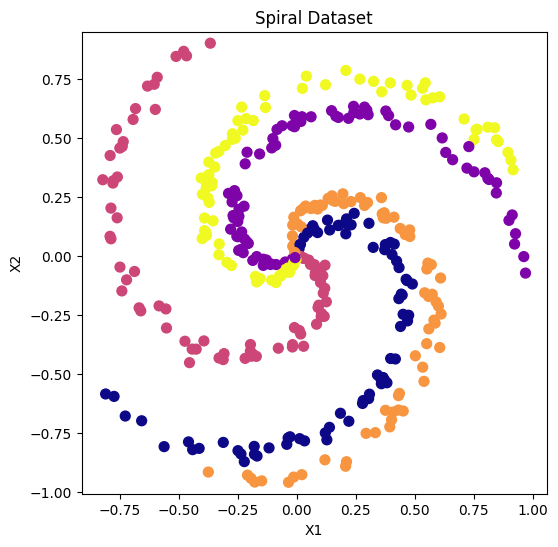

In [5]:
# Visualize test dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='plasma', s=50)
plt.title('Spiral Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axis('equal')
plt.show()

## 3 – Load Trained CNN Model

In [6]:
# Load the trained CNN model
model = SimpleClassifier(num_classes=5)
model = load_model(model, 'data/models/simple_classifier.pth', device=device)
model = model.to(device)

# Print number of parameters
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Total parameters: 2,437


## 4 – Compute LiRPA Bounds (Offline Phase)

**Important**: This step is computationally intensive for high-dimensional data.
We use a small subset of samples per class to keep computation manageable.

For production use, you would:
1. Compute bounds once on a larger dataset
2. Save the bounds to disk
3. Load pre-computed bounds for counterfactual generation

In [7]:
# Configuration
EPS = 0.2           # Perturbation radius (in pixel value space [0,1])
N_PER_CLASS = 50   # Number of samples per class (keep small for MNIST)

print(f"Computing LiRPA bounds with:")
print(f"  ε = {EPS} (L∞ perturbation)")
print(f"  {N_PER_CLASS} samples per class")

Computing LiRPA bounds with:
  ε = 0.2 (L∞ perturbation)
  50 samples per class


In [8]:
# Create a subset dataset for bound computation
subset_data = []
for label in range(num_classes):
    for i in range(min(N_PER_CLASS, len(label_dataset[label]))):
        subset_data.append((label_dataset[label][i], torch.tensor(label)))

print(f"Subset dataset size: {len(subset_data)} samples")

Subset dataset size: 250 samples


In [9]:
# Compute bounds
approximator = PreimageApproximation(
    model, 
    subset_data, 
    device, 
    cnn=False  # Important: set to True for CNN models
)

# Estimate memory requirements and get recommendation
print("Estimating memory requirements...")
mem_info = approximator.estimate_memory_usage(
    n_samples_per_class=N_PER_CLASS,
    verbose=True
)

# Use recommended batch size to avoid OOM errors
all_bounds = approximator.compute_all_bounds(
    eps=EPS, 
    norm=2,
    max_samples_per_class=N_PER_CLASS,
    batch_size=64
)

print("\nBounds computed for all classes:")
for label in all_bounds:
    print(f"  Class {label}: {all_bounds[label]['lA'].shape[0]} polytopes")

Estimating memory requirements...
Memory Estimation for 50 samples/class:
  Sample shape: torch.Size([2])
  Estimated memory per sample: 0.00 MB
  Total estimated memory: 0.03 MB
  GPU total memory: 11865.12 MB
  Recommended batch size: 4147161


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 15.36it/s]


Bounds computed for all classes:
  Class 0: 50 polytopes
  Class 1: 50 polytopes
  Class 2: 50 polytopes
  Class 3: 50 polytopes
  Class 4: 50 polytopes


## 5 – Build Counterfactual Sampler

In [10]:
# Initialize CPP sampler
sampler = CounterfactualSampler(solver='ECOS', verbose=True, distance_norm=1)
sampler.build_all_atlases(all_bounds, eps=EPS)

print(f"\nSampler ready with {len(sampler.atlases)} digit atlases")

Built atlas for class 0: 50 polytopes, dim=2, eps=0.2
Built atlas for class 1: 50 polytopes, dim=2, eps=0.2
Built atlas for class 2: 50 polytopes, dim=2, eps=0.2
Built atlas for class 3: 50 polytopes, dim=2, eps=0.2
Built atlas for class 4: 50 polytopes, dim=2, eps=0.2
Built 5 atlases

Sampler ready with 5 digit atlases


## 6 – Generate Single Counterfactual

Transform a digit image to look like another digit.

In [11]:
# Select source and target digits
source_digit = 0
target_digit = 4
query_idx = 0

# Get query image (flatten for LiRPA)
x_query = all_bounds[source_digit]['X'][query_idx].flatten()
print(f"Query image from digit {source_digit}")
print(f"Shape: {x_query.shape}")
print(f"Pixel value range: [{x_query.min():.3f}, {x_query.max():.3f}]")

Query image from digit 0
Shape: (2,)
Pixel value range: [-0.726, 0.138]


In [12]:
# Generate counterfactual
result = sampler.generate_counterfactual(
    x_query,
    target_label=target_digit,
    k_candidates=15,  # Try fewer candidates for faster computation
    return_all_candidates=True
)

if result['success']:
    print(f"\n✓ SUCCESS: Found counterfactual at distance {result['distance']:.4f}")
    print(f"  Feasible projections: {result['n_candidates_feasible']}/{result['n_candidates_tried']}")
else:
    print(f"\n✗ FAILED: Could not find feasible counterfactual")
    print(f"  Try: increasing k_candidates, using different source/target, or increasing ε")

Selected 15 nearest polytopes from 50 total
SUCCESS: distance=0.7498, feasible=15/15

✓ SUCCESS: Found counterfactual at distance 0.7498
  Feasible projections: 15/15


## 7 – Verify Counterfactual

In [13]:
if result['success']:
    # Reshape counterfactual back to image format for model input
    x_cf = torch.tensor(
        result['counterfactual'], 
        dtype=torch.float32
    )
    
    # Get model prediction
    model.eval()
    with torch.no_grad():
        output = model(x_cf.to(device))
        pred = output.argmax(dim=0).item()
    
    print(f"Model prediction: {pred}")
    print(f"Target digit: {target_digit}")
    print(f"Correct: {pred == target_digit}")

Model prediction: 4
Target digit: 4
Correct: True


## 8 – Visualize Counterfactual Transformation

In [22]:
if result['success']:
    # Prepare images
    img_query = x_query.reshape(28, 28)
    img_cf = result['counterfactual'].reshape(28, 28)
    img_diff = img_cf - img_query
    
    # Create visualization
    fig, axes = plt.subplots(1, 5, figsize=(16, 4))
    
    # Original image
    axes[0].imshow(img_query, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Original\n(Digit {source_digit})', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Counterfactual image
    axes[1].imshow(img_cf, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'Counterfactual\n(Digit {target_digit})', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Difference (what changed)
    im = axes[2].imshow(img_diff, cmap='RdBu', vmin=-1, vmax=1)
    axes[2].set_title(f'Difference\n(L2 dist: {result["distance"]:.3f})', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    
    # Absolute difference
    im = axes[3].imshow(np.abs(img_diff), cmap='hot', vmin=0, vmax=1)
    axes[3].set_title('Absolute Change\n(magnitude)', fontsize=12, fontweight='bold')
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics about the change
    print(f"\nChange statistics:")
    print(f"  Pixels changed (|diff| > 0.01): {(np.abs(img_diff) > 0.01).sum()}/784")
    print(f"  Max absolute change: {np.abs(img_diff).max():.3f}")
    print(f"  Mean absolute change: {np.abs(img_diff).mean():.3f}")
    print(f"  L2 distance: {result['distance']:.3f}")
    print(f"  L∞ distance: {np.abs(img_diff).max():.3f}")

ValueError: cannot reshape array of size 2 into shape (28,28)

## 9 – Generate Multiple Counterfactuals

Create a grid showing transformations of different source digits to the same target.

In [17]:
# Configuration
target_digit = 4
source_digits = [0, 1, 2, 3]  # Which digits to transform
n_samples = len(source_digits)

print(f"Generating counterfactuals: all → digit {target_digit}\n")

# Generate counterfactuals
results_grid = []
for source in source_digits:
    if source == target_digit:
        print(f"Skipping digit {source} (same as target)")
        continue
    
    x_query = all_bounds[source]['X'][0].flatten()
    result = sampler.generate_counterfactual(
        x_query,
        target_label=target_digit,
        k_candidates=5
    )
    results_grid.append((source, x_query, result))
    
    status = '✓' if result['success'] else '✗'
    dist = f"{result['distance']:.3f}" if result['success'] else 'N/A'
    print(f"{status} {source} → {target_digit}: distance = {dist}")

Generating counterfactuals: all → digit 4

Selected 5 nearest polytopes from 50 total
SUCCESS: distance=0.7510, feasible=5/5
✓ 0 → 4: distance = 0.751
Selected 5 nearest polytopes from 50 total
SUCCESS: distance=0.0868, feasible=5/5
✓ 1 → 4: distance = 0.087
Selected 5 nearest polytopes from 50 total
SUCCESS: distance=0.2807, feasible=5/5
✓ 2 → 4: distance = 0.281
Selected 5 nearest polytopes from 50 total
SUCCESS: distance=0.6792, feasible=5/5
✓ 3 → 4: distance = 0.679
